# Transformer-JEPA — unified thesis evaluation (config-driven)

**Authoritative thesis protocol:** `unified_eval_v2`. Change only `CONFIG_NAME` in section 1 to evaluate a different Transformer-JEPA experiment: the run identity derives from the YAML and the checkpoint is verified against it. Run cells in order.

Each expensive stage is a separate cell and saves immediately under `RUN_DIR/unified_eval/final`, so a Colab disconnect does not erase completed stages.

## 1. Mount Drive, select the experiment YAML, build the exact split, and copy `final.pt`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import hashlib
from importlib import metadata as importlib_metadata
import json
import os
import shutil
import subprocess
import sys
import yaml

PROJECT_ROOT = Path('/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code')
assert (PROJECT_ROOT / 'pyproject.toml').is_file(), PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(PROJECT_ROOT)], check=True)
os.chdir(PROJECT_ROOT)

# === SINGLE SOURCE OF TRUTH ===
# Change this filename to evaluate a different Transformer-JEPA experiment.
# Run name, run dir, board size, and the expected objective identity all
# derive from the YAML below; the checkpoint is then verified against it.
CONFIG_NAME = 'jepa_v4_multi_pos_k4_hd_all_positions.yml'

CONFIG_PATH = PROJECT_ROOT / 'configs' / CONFIG_NAME
assert CONFIG_PATH.is_file(), CONFIG_PATH
EXPERIMENT_CONFIG = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
yaml_experiment = EXPERIMENT_CONFIG.get('experiment', {})
yaml_data = EXPERIMENT_CONFIG.get('data', {})
yaml_model = EXPERIMENT_CONFIG.get('model', {})
yaml_objective = EXPERIMENT_CONFIG.get('objective', {})
yaml_paths = EXPERIMENT_CONFIG.get('paths', {})

ARCHITECTURE = str(yaml_model.get('encoder_architecture', 'transformer'))
assert ARCHITECTURE == 'transformer', 'This notebook evaluates Transformer-JEPA runs.'
OBJECTIVE = str(yaml_objective.get('objective_class', 'jepa'))
SUPPORTED_OBJECTIVES = {'jepa', 'jepa_hard_disjoint_action'}
assert OBJECTIVE in SUPPORTED_OBJECTIVES, (
    f'This notebook supports objective_class in {sorted(SUPPORTED_OBJECTIVES)}; '
    f'got {OBJECTIVE!r}.'
)
# Horizon-1 for v1/v2/v5/v6; v3/v4 use a multi-step horizon K. v6 omits
# prediction_horizon from its YAML (implicit K=1). The checkpoint is verified
# against EXPECTED_HORIZON in section 2.
EXPECTED_HORIZON = int(yaml_objective.get('prediction_horizon', 1))
assert EXPECTED_HORIZON >= 1, EXPECTED_HORIZON

RUN_NAME = str(yaml_experiment.get('name'))
BOARD_SIZE = int(yaml_data.get('board_size'))
DATA_DIR = Path(str(yaml_paths.get('data_dir')))
RUN_DIR = Path(str(yaml_paths.get('drive_sync_dir')))
EXPECTED_POSITION_SAMPLING = str(yaml_objective.get('position_sampling', 'random'))

# Expected objective identity from the YAML; section 2 checks the checkpoint
# reports exactly the same identity before any metric is computed.
EXPECTED_VARIANT = str(yaml_experiment.get('variant', 'v1'))
EXPECTED_INTERNAL_VARIANT = {
    'v1': 'jepa_v1', 'v2': 'jepa_v2',
    # v3/v4 are experiment families built on the v2 EMA target topology.
    'v3': 'jepa_v2', 'v4': 'jepa_v2',
    'v6': 'jepa_v6_hard_disjoint_action',
}[EXPECTED_VARIANT]
EXPECTED_VIEW_MODE = str(yaml_objective.get('view_mode'))
EXPECTED_LOSS_TYPE = str(yaml_objective.get('loss_type'))
EXPECTED_USE_EMA = (
    bool(yaml_objective['use_ema_target'])
    if yaml_objective.get('use_ema_target') is not None
    else EXPECTED_VARIANT == 'v2'
)
OBJECTIVE_LABEL = (
    f"jepa_{EXPECTED_VARIANT}_{EXPECTED_LOSS_TYPE}_"
    f"{EXPECTED_VIEW_MODE.replace('_future', '')}"
)

CHECKPOINT_NAME = 'final.pt'  # thesis headline evaluation is always explicit
EXPECTED_PRETRAINING_CHUNKS = 200
MAMBA_SSM_VERSION = '2.3.2.post1'
CAUSAL_CONV1D_VERSION = '1.6.2.post1'
DRIVE_CKPT = RUN_DIR / CHECKPOINT_NAME

assert DATA_DIR.is_dir(), DATA_DIR
assert RUN_DIR.is_dir(), RUN_DIR
assert DRIVE_CKPT.is_file(), (
    f'Expected exact final checkpoint {DRIVE_CKPT}. '
    'No automatic checkpoint fallback is permitted.'
)

def installed_version(distribution_name):
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return None

import torch
assert torch.cuda.is_available(), 'Select a CUDA GPU runtime in Colab.'
assert torch.cuda.is_bf16_supported(), 'The unified headline protocol requires CUDA bf16 support.'
device = torch.device('cuda:0')
MAMBA_SSM_RUNTIME_VERSION = None
CAUSAL_CONV1D_RUNTIME_VERSION = None

from othello_research.evaluation.unified import (
    PROTOCOL_ID,
    UnifiedEvalConfig,
    UnifiedEvaluator,
    build_evaluation_split,
    file_sha256,
)

protocol_config = UnifiedEvalConfig(board_size=BOARD_SIZE)
all_chunks = sorted(DATA_DIR.glob('*.pickle'))
split = build_evaluation_split(all_chunks, protocol_config)

# Exact common split: 0:200 / 200:220 / 220:229 / 229:238.
assert split.pretraining == tuple(all_chunks[0:200])
assert split.downstream_train == tuple(all_chunks[200:220])
assert split.selection == tuple(all_chunks[220:229])
assert split.test == tuple(all_chunks[229:238])

DATA_MANIFEST_PATH = DATA_DIR / 'manifest.json'
assert DATA_MANIFEST_PATH.is_file(), (
    f'Authoritative evaluation requires {DATA_MANIFEST_PATH}; corpus counts '
    'must not be inferred by scanning pickle payloads.'
)
DATA_MANIFEST_PAYLOAD = json.loads(DATA_MANIFEST_PATH.read_text(encoding='utf-8'))
SHARD_COUNTS = dict(DATA_MANIFEST_PAYLOAD.get('shard_counts') or ())
for shard in DATA_MANIFEST_PAYLOAD.get('shards') or ():
    name = str(shard['filename'])
    count = int(shard['count'])
    if name in SHARD_COUNTS:
        assert int(SHARD_COUNTS[name]) == count, (name, SHARD_COUNTS[name], count)
    SHARD_COUNTS[name] = count
missing_counts = [path.name for path in all_chunks if path.name not in SHARD_COUNTS]
assert not missing_counts, f'Manifest lacks shard counts: {missing_counts[:3]}'
EXPECTED_PRETRAIN_GAMES = sum(int(SHARD_COUNTS[path.name]) for path in split.pretraining)

SHARD_SHA256 = dict()
for shard in DATA_MANIFEST_PAYLOAD.get('shards') or ():
    if shard.get('sha256'):
        SHARD_SHA256[str(shard['filename'])] = str(shard['sha256'])
if all(path.name in SHARD_SHA256 for path in all_chunks):
    content_digest = hashlib.sha256()
    for path in all_chunks:
        content_digest.update(path.name.encode('utf-8'))
        content_digest.update(SHARD_SHA256[path.name].encode('ascii'))
    SPLIT_CONTENT_SHA256 = content_digest.hexdigest()
    DATA_MANIFEST_IDENTITY = 'per-shard-sha256'
else:
    SPLIT_CONTENT_SHA256 = None
    DATA_MANIFEST_IDENTITY = 'counts-only'

source_digest = hashlib.sha256()
for source_path in sorted((PROJECT_ROOT / 'othello_research').rglob('*.py')):
    relative = source_path.relative_to(PROJECT_ROOT).as_posix().encode('utf-8')
    source_digest.update(len(relative).to_bytes(8, 'big'))
    source_digest.update(relative)
    source_digest.update(source_path.read_bytes())
PROJECT_SOURCE_SHA256 = source_digest.hexdigest()

# Always overwrite the local copy: a stale checkpoint can never survive a rerun.
LOCAL_CKPT_DIR = Path('/content/unified_eval_checkpoints') / RUN_NAME
LOCAL_CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CKPT = LOCAL_CKPT_DIR / CHECKPOINT_NAME
shutil.copy2(DRIVE_CKPT, LOCAL_CKPT)
CHECKPOINT_SHA256 = file_sha256(LOCAL_CKPT)
CHECKPOINT_BYTES = LOCAL_CKPT.stat().st_size
DATA_MANIFEST_SHA256 = file_sha256(DATA_MANIFEST_PATH)

print('protocol         :', PROTOCOL_ID)
print('device / bf16    :', torch.cuda.get_device_name(0), torch.cuda.is_bf16_supported())
print('config           :', CONFIG_NAME)
print('run              :', RUN_NAME)
print('objective        :', OBJECTIVE_LABEL,
      f'(view={EXPECTED_VIEW_MODE}, loss={EXPECTED_LOSS_TYPE}, ema={EXPECTED_USE_EMA})')
print('board            :', f'{BOARD_SIZE}x{BOARD_SIZE}')
print('checkpoint       :', DRIVE_CKPT)
print('checkpoint SHA256:', CHECKPOINT_SHA256)
print('data manifest    :', DATA_MANIFEST_PATH)
print('manifest SHA256  :', DATA_MANIFEST_SHA256)
print('manifest identity:', DATA_MANIFEST_IDENTITY)
print('content SHA256   :', SPLIT_CONTENT_SHA256 or 'unavailable (counts-only legacy manifest)')
print('source SHA256    :', PROJECT_SOURCE_SHA256)
print('pretrain games   :', f'{EXPECTED_PRETRAIN_GAMES:,}')
print('split SHA256     :', split.manifest_hash)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
protocol         : unified_eval_v2
device / bf16    : NVIDIA L4 True
config           : jepa_v4_multi_pos_k4_hd_all_positions.yml
run              : jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16
objective        : jepa_v4_smooth_l1_hard_disjoint (view=hard_disjoint_future, loss=smooth_l1, ema=True)
board            : 8x8
checkpoint       : /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/final.pt
checkpoint SHA256: a7ac57ac972ea358da7c23fbb4c9015f9c292842b25979700844359f82236ba0
data manifest    : /content/drive/MyDrive/Master_Thesis_Artifacts/data/othello_8x8/manifest.json
manifest SHA256  : a0994e3e27b032e593894e0fc9f2626094b4b75e91179f4803fd0f23939b1325
manifest identity: counts-only
content SHA256   : unavailable (counts-only legacy manifest)
source SHA256    : 4233de4099701ae0d31629cff5bc04787741d43e39ba117b3a

## 2. Validate and load the frozen checkpoint; initialize the evaluator

In [ ]:
from othello_research.training.train_jepa import build_model_from_checkpoint

ckpt = torch.load(LOCAL_CKPT, map_location='cpu', weights_only=False)
checkpoint_games_seen = int(ckpt.get('games_seen', -1))
checkpoint_chunk_count = int(ckpt.get('chunk_count', -1))
checkpoint_model_config = dict(ckpt.get('model_config') or ckpt.get('jepa_config') or {})
checkpoint_train_config = dict(ckpt.get('train_config') or {})
assert checkpoint_games_seen == EXPECTED_PRETRAIN_GAMES, (
    f'Checkpoint games_seen={checkpoint_games_seen:,}, but the manifest says '
    f'the exact first-200-shard budget is {EXPECTED_PRETRAIN_GAMES:,}.'
)
assert checkpoint_chunk_count == EXPECTED_PRETRAINING_CHUNKS, (
    checkpoint_chunk_count, EXPECTED_PRETRAINING_CHUNKS
)
assert int(checkpoint_train_config.get('passes_over_data', -1)) == 1
assert checkpoint_model_config.get('objective_class', 'jepa') == OBJECTIVE, (
    checkpoint_model_config.get('objective_class', 'jepa'), OBJECTIVE
)

# The checkpoint must report exactly the objective identity the selected YAML
# declares; a mismatch means the run dir and config have drifted apart.
assert checkpoint_model_config.get('view_mode') == EXPECTED_VIEW_MODE, (
    checkpoint_model_config.get('view_mode'), EXPECTED_VIEW_MODE
)
assert checkpoint_model_config.get('loss_type') == EXPECTED_LOSS_TYPE, (
    checkpoint_model_config.get('loss_type'), EXPECTED_LOSS_TYPE
)
assert checkpoint_model_config.get('variant') == EXPECTED_INTERNAL_VARIANT, (
    checkpoint_model_config.get('variant'), EXPECTED_INTERNAL_VARIANT
)
checkpoint_use_ema = checkpoint_model_config.get('use_ema_target')
if checkpoint_use_ema is None:
    checkpoint_use_ema = EXPECTED_INTERNAL_VARIANT == 'jepa_v2'
assert bool(checkpoint_use_ema) == EXPECTED_USE_EMA, (
    checkpoint_use_ema, EXPECTED_USE_EMA
)
assert int(checkpoint_model_config.get('prediction_horizon', 1)) == EXPECTED_HORIZON, (
    checkpoint_model_config.get('prediction_horizon', 1), EXPECTED_HORIZON
)
assert checkpoint_model_config.get('encoder_architecture', 'transformer') == ARCHITECTURE
assert checkpoint_train_config.get('position_sampling', 'random') == EXPECTED_POSITION_SAMPLING

jepa_model, model_cfg = build_model_from_checkpoint(ckpt)
jepa_model.load_state_dict(ckpt['model'])
assert int(model_cfg.board_size) == BOARD_SIZE, (model_cfg.board_size, BOARD_SIZE)
assert str(model_cfg.encoder_architecture) == ARCHITECTURE
jepa_model.to(device).eval()
for parameter in jepa_model.parameters():
    parameter.requires_grad_(False)
encoder = jepa_model.context_encoder
model_config_snapshot = dict(vars(model_cfg)) if hasattr(model_cfg, '__dict__') else str(model_cfg)
training_precision = (
    checkpoint_train_config.get('precision')
    or checkpoint_train_config.get('amp_dtype')
    or checkpoint_train_config.get('mixed_precision')
    or ckpt.get('precision')
)
print('checkpoint training precision:', training_precision or 'unreported')
if 'bf16' not in str(training_precision).lower() and 'bfloat16' not in str(training_precision).lower():
    print('INTERPRETATION NOTE: evaluation is unified bf16/fp32, but this checkpoint '
          'was not verified as bf16-trained; retain training precision as a covariate.')

run_metadata = {
    'run_name': RUN_NAME,
    'architecture': ARCHITECTURE,
    'objective': OBJECTIVE_LABEL,
    'position_sampling': EXPECTED_POSITION_SAMPLING,
    'board_size': BOARD_SIZE,
    'config_name': CONFIG_NAME,
    'checkpoint_name': CHECKPOINT_NAME,
    'checkpoint_drive_path': str(DRIVE_CKPT),
    'checkpoint_local_path': str(LOCAL_CKPT),
    'checkpoint_sha256': CHECKPOINT_SHA256,
    'checkpoint_bytes': CHECKPOINT_BYTES,
    'data_manifest_path': str(DATA_MANIFEST_PATH) if DATA_MANIFEST_SHA256 else None,
    'data_manifest_sha256': DATA_MANIFEST_SHA256,
    'data_manifest_identity': DATA_MANIFEST_IDENTITY,
    'split_content_sha256': SPLIT_CONTENT_SHA256,
    'project_source_sha256': PROJECT_SOURCE_SHA256,
    'step': ckpt.get('step'),
    'games_seen': ckpt.get('games_seen'),
    'chunk_count': ckpt.get('chunk_count'),
    'expected_pretrain_games': EXPECTED_PRETRAIN_GAMES,
    'training_precision': training_precision,
    'model_config': model_config_snapshot,
    'train_config': checkpoint_train_config,
    'encoder_parameters': sum(p.numel() for p in encoder.parameters()),
    'total_parameters': sum(p.numel() for p in jepa_model.parameters()),
    'mamba_backend': getattr(model_cfg, 'mamba_backend', None),
    'mamba_ssm_version': MAMBA_SSM_RUNTIME_VERSION,
    'causal_conv1d_version': CAUSAL_CONV1D_RUNTIME_VERSION,
    'view_mode': checkpoint_model_config.get('view_mode'),
    'loss_type': checkpoint_model_config.get('loss_type'),
}
OUTPUT_DIR = RUN_DIR / 'unified_eval' / LOCAL_CKPT.stem
evaluator = UnifiedEvaluator(
    encoder=encoder,
    split=split,
    config=protocol_config,
    device=device,
    output_dir=OUTPUT_DIR,
    run_metadata=run_metadata,
)
evaluator.print_protocol()
print('artifacts:', OUTPUT_DIR)

# Presentation helpers: compact thesis tables instead of raw result dicts.
import pandas as pd
from IPython.display import display


def _topk_legal(metrics, k):
    values = metrics['topk_legal']
    return float(values.get(k, values.get(str(k))))


def show_legal_summary(results_by_head):
    rows = []
    for head_type, result in results_by_head.items():
        metrics = result['test_legal']
        rows.append({
            'readout': head_type.upper(),
            'top-1 legal': f"{100 * float(metrics['top1_legal_per_token']):.2f}%",
            'top-3 legal fraction': f"{100 * _topk_legal(metrics, 3):.2f}%",
            'top-5 legal fraction': f"{100 * _topk_legal(metrics, 5):.2f}%",
            'legal prob mass': f"{100 * float(metrics['legal_prob_mass_per_token']):.2f}%",
        })
    frame = pd.DataFrame(rows).set_index('readout')
    display(frame)
    return frame


def show_board_probe_layers(result, label):
    selected = {
        mode: int(result['selected'][mode]['layer'])
        for mode in ('absolute', 'relative')
    }
    rows = []
    for layer in result['layers']:
        layer = int(layer)
        test = result['test_metrics'][str(layer)]
        rows.append({
            'layer': f'L{layer}',
            'absolute acc': f"{100 * float(test['absolute']['accuracy']):.2f}%",
            'absolute macro': f"{100 * float(test['absolute']['macro_balanced_accuracy']):.2f}%",
            'relative acc': f"{100 * float(test['relative']['accuracy']):.2f}%",
            'relative macro': f"{100 * float(test['relative']['macro_balanced_accuracy']):.2f}%",
            'selected': ' + '.join(
                mode for mode in ('absolute', 'relative') if selected[mode] == layer
            ),
        })
    frame = pd.DataFrame(rows).set_index('layer')
    print(
        f"{label}: per-layer board-state accuracy on the untouched test split "
        f"(selection-split layer choice: absolute=L{selected['absolute']}, "
        f"relative=L{selected['relative']})"
    )
    display(frame)
    return frame


# Chart helpers: visual summaries of the saved evaluation results.
import matplotlib.pyplot as plt

_SERIES_COLORS = {'linear': '#2a78d6', 'mlp': '#1baf7a', 'native': '#eda100'}


def _chart_topk(metrics, k):
    values = metrics['topk_legal']
    return float(values.get(k, values.get(str(k))))


def plot_legal_metrics(results):
    heads = []
    for name in ('linear', 'mlp'):
        result = results.get('frozen_next_move', {}).get(name)
        if result:
            heads.append((name, result['test_legal']))
    native = results.get('native_ar')
    if native:
        heads.append(('native', native))
    if not heads:
        print('plot_legal_metrics: no legal-move results yet')
        return
    labels = ['top-1 legal', 'top-3 legal', 'top-5 legal', 'legal mass']
    fig, ax = plt.subplots(figsize=(8, 3.4))
    width = 0.8 / len(heads)
    for i, (name, m) in enumerate(heads):
        values = [
            100 * float(m['top1_legal_per_token']),
            100 * _chart_topk(m, 3),
            100 * _chart_topk(m, 5),
            100 * float(m['legal_prob_mass_per_token']),
        ]
        xs = [j + (i - (len(heads) - 1) / 2) * width for j in range(4)]
        bars = ax.bar(xs, values, width=width * 0.92, label=name,
                      color=_SERIES_COLORS[name])
        ax.bar_label(bars, fmt='%.1f', fontsize=8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 108)
    ax.set_ylabel('%')
    ax.legend(frameon=False)
    ax.set_title('Next-move legality (held-out test games)')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_board_probe_layers(results):
    probes = [(p, results.get('board_state', {}).get(p)) for p in ('linear', 'mlp')]
    probes = [(p, r) for p, r in probes if r]
    if not probes:
        print('plot_board_probe_layers: no board-probe results yet')
        return
    fig, axes = plt.subplots(1, len(probes), figsize=(5.2 * len(probes), 3.4), sharey=True)
    if len(probes) == 1:
        axes = [axes]
    for ax, (name, r) in zip(axes, probes):
        layers = [int(l) for l in r['layers']]
        for mode, color in (('relative', '#2a78d6'), ('absolute', '#1baf7a')):
            accs = [100 * float(r['test_metrics'][str(l)][mode]['accuracy']) for l in layers]
            ax.plot(layers, accs, marker='o', markersize=3.5, color=color, label=mode)
            selected = int(r['selected'][mode]['layer'])
            ax.scatter([selected],
                       [100 * float(r['test_metrics'][str(selected)][mode]['accuracy'])],
                       s=70, facecolors='none', edgecolors=color, zorder=3)
        ax.set_title(f'{name} board probe (test, o = selected layer)')
        ax.set_xlabel('layer')
        ax.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('test accuracy %')
    axes[0].legend(frameon=False)
    plt.tight_layout()
    plt.show()

checkpoint training precision: bf16
Protocol             : unified_eval_v2
Board                : 8x8
Encoder/readout      : bf16 / fp32
Shard split          : 0:200 pretrain, 200:220 readout train, then 9 selection + 9 test
Split manifest SHA256: 9b203eaa68ee72bda13dbeae13566df1869b618995743b21c52397aaf9b5146f
artifacts: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final


## 3. Frozen linear next-move readout

This stage saves its artifact and updates the shared results JSON before returning.

In [ ]:
linear_result = evaluator.run_frozen_head('linear')
_ = show_legal_summary({'linear': linear_result})

linear head epoch=1/1 chunk=1/20 games=99,999 tokens=5,897,008 loss=2.9129 dt=22.4s
linear head epoch=1/1 chunk=2/20 games=199,999 tokens=11,794,072 loss=2.4321 dt=22.4s
linear head epoch=1/1 chunk=3/20 games=299,998 tokens=17,690,693 loss=2.3699 dt=22.0s
linear head epoch=1/1 chunk=4/20 games=399,996 tokens=23,587,330 loss=2.3467 dt=22.0s
linear head epoch=1/1 chunk=5/20 games=499,995 tokens=29,484,140 loss=2.3342 dt=22.1s
linear head epoch=1/1 chunk=6/20 games=599,995 tokens=35,380,187 loss=2.3256 dt=22.1s
linear head epoch=1/1 chunk=7/20 games=699,994 tokens=41,276,557 loss=2.3196 dt=22.2s
linear head epoch=1/1 chunk=8/20 games=799,993 tokens=47,172,922 loss=2.3147 dt=22.1s
linear head epoch=1/1 chunk=9/20 games=899,992 tokens=53,069,691 loss=2.3105 dt=22.1s
linear head epoch=1/1 chunk=10/20 games=999,992 tokens=58,966,366 loss=2.3080 dt=22.1s
linear head epoch=1/1 chunk=11/20 games=1,099,991 tokens=64,863,324 loss=2.3058 dt=22.1s
linear head epoch=1/1 chunk=12/20 games=1,199,989 to

legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

,top-1 legal,top-3 legal fraction,top-5 legal fraction,legal prob mass
readout,,,,
LINEAR,97.48%,95.15%,90.86%,87.76%


## 4. Frozen MLP next-move readout

This stage saves its artifact and updates the shared results JSON before returning.

In [ ]:
mlp_result = evaluator.run_frozen_head('mlp')
_ = show_legal_summary({'mlp': mlp_result})

mlp head epoch=1/1 chunk=1/20 games=99,999 tokens=5,897,008 loss=2.5701 dt=23.3s
mlp head epoch=1/1 chunk=2/20 games=199,999 tokens=11,794,072 loss=2.2874 dt=23.3s
mlp head epoch=1/1 chunk=3/20 games=299,998 tokens=17,690,693 loss=2.2675 dt=23.1s
mlp head epoch=1/1 chunk=4/20 games=399,996 tokens=23,587,330 loss=2.2578 dt=23.1s
mlp head epoch=1/1 chunk=5/20 games=499,995 tokens=29,484,140 loss=2.2499 dt=23.2s
mlp head epoch=1/1 chunk=6/20 games=599,995 tokens=35,380,187 loss=2.2427 dt=23.2s
mlp head epoch=1/1 chunk=7/20 games=699,994 tokens=41,276,557 loss=2.2366 dt=23.2s
mlp head epoch=1/1 chunk=8/20 games=799,993 tokens=47,172,922 loss=2.2308 dt=23.2s
mlp head epoch=1/1 chunk=9/20 games=899,992 tokens=53,069,691 loss=2.2248 dt=23.2s
mlp head epoch=1/1 chunk=10/20 games=999,992 tokens=58,966,366 loss=2.2201 dt=23.2s
mlp head epoch=1/1 chunk=11/20 games=1,099,991 tokens=64,863,324 loss=2.2149 dt=23.2s
mlp head epoch=1/1 chunk=12/20 games=1,199,989 tokens=70,759,942 loss=2.2098 dt=23.2s

legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

,top-1 legal,top-3 legal fraction,top-5 legal fraction,legal prob mass
readout,,,,
MLP,97.68%,95.00%,90.76%,91.31%


## 5. Linear board-state probe

This stage saves its artifact and updates the shared results JSON before returning.

In [ ]:
board_linear_result = evaluator.run_board_probe('linear')
_ = show_board_probe_layers(board_linear_result, 'Linear board probe')

Extracting fixed board-position features: train=20,000, selection=2,048, test=8,192
Linear board probe: per-layer board-state accuracy on the untouched test split (selection-split layer choice: absolute=L4, relative=L3)


,absolute acc,absolute macro,relative acc,relative macro,selected
layer,,,,,
L0,62.62%,55.80%,64.92%,58.53%,
L1,75.19%,68.44%,87.77%,84.43%,
L2,75.47%,68.75%,90.84%,88.26%,
L3,77.57%,71.43%,91.76%,89.43%,relative
L4,81.36%,76.29%,90.70%,88.09%,absolute
L5,81.25%,76.17%,88.84%,85.71%,
L6,80.64%,75.41%,87.92%,84.53%,
L7,80.51%,75.26%,87.81%,84.40%,
L8,80.36%,75.06%,87.55%,84.06%,


## 6. MLP board-state probe

This stage saves its artifact and updates the shared results JSON before returning.

In [ ]:
board_mlp_result = evaluator.run_board_probe('mlp')
_ = show_board_probe_layers(board_mlp_result, 'MLP board probe')

MLP board probe: per-layer board-state accuracy on the untouched test split (selection-split layer choice: absolute=L2, relative=L3)


,absolute acc,absolute macro,relative acc,relative macro,selected
layer,,,,,
L0,64.85%,58.40%,65.24%,58.67%,
L1,78.98%,73.35%,86.49%,82.81%,
L2,81.17%,76.04%,90.19%,87.39%,absolute
L3,79.39%,73.76%,90.90%,88.32%,relative
L4,80.30%,74.95%,89.49%,86.51%,
L5,79.76%,74.31%,86.58%,82.78%,
L6,78.68%,72.98%,85.12%,80.95%,
L7,78.52%,72.77%,84.63%,80.30%,
L8,78.39%,72.62%,84.51%,80.17%,


## 7. Write and display the consolidated summary

# Unified evaluation: jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16

- **Protocol:** `unified_eval_v2`
- **Board:** `8x8`
- **Architecture/objective:** `transformer` / `jepa_v4_smooth_l1_hard_disjoint`
- **Checkpoint:** `final.pt` (step `78200`, games `19,999,840`)
- **Checkpoint SHA-256:** `a7ac57ac972ea358da7c23fbb4c9015f9c292842b25979700844359f82236ba0`
- **Split manifest SHA-256:** `9b203eaa68ee72bda13dbeae13566df1869b618995743b21c52397aaf9b5146f`
- **Data-manifest SHA-256:** `a0994e3e27b032e593894e0fc9f2626094b4b75e91179f4803fd0f23939b1325`
- **Per-shard corpus identity:** `unavailable-counts-only`
- **Project-source SHA-256:** `4233de4099701ae0d31629cff5bc04787741d43e39ba117b3a9036dfd9b149a4`
- **Exact pretraining budget:** `19,999,840` games / `200` shards
- **Checkpoint-reported training precision:** `bf16`
- **Precision:** frozen encoder bf16; cached features/readouts/metrics fp32
- **Pass policy:** effective side-to-move; implicit-pass positions are scored

## Frozen-encoder next-move readouts (primary comparison)

| Readout | Top-1 legal | Top-3 legal fraction | Top-5 legal fraction | Legal mass |
|---|---:|---:|---:|---:|
| LINEAR | 97.48% | 95.15% | 90.86% | 87.76% |
| MLP | 97.68% | 95.00% | 90.76% | 91.31% |

## Phase-stratified board-state probes

Layers are selected only on the selection split; every number in the `Test` columns comes from the untouched final test split.

| Probe | Labels | Selected layer | Depth | Val macro | Test macro | Test overall | Occupied | Empty |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| LINEAR | absolute | L4 | 0.500 | 76.21% | 76.29% | 81.36% | 64.51% | 99.90% |
| LINEAR | relative | L3 | 0.375 | 89.42% | 89.43% | 91.76% | 84.30% | 99.96% |
| MLP | absolute | L2 | 0.250 | 76.35% | 76.04% | 81.17% | 64.10% | 99.96% |
| MLP | relative | L3 | 0.375 | 88.36% | 88.32% | 90.90% | 82.68% | 99.94% |

## Artifacts and timing

- Results JSON: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/results__unified_eval_v2.json`
- linear next-move head: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/linear_next_move_head__unified_eval_v2.pt`
- mlp next-move head: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/mlp_next_move_head__unified_eval_v2.pt`
- linear board probe: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/linear_board_probe__unified_eval_v2.pt`
- mlp board probe: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/mlp_board_probe__unified_eval_v2.pt`
- Position manifest: `/content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/position_manifest__unified_eval_v2.json`

| Stage | Wall time |
|---|---:|
| frozen_head_linear | 557.8 s |
| frozen_head_mlp | 579.8 s |
| board_feature_extraction | 180.2 s |
| board_probe_linear | 11.1 s |
| board_probe_mlp | 15.2 s |


=== Frozen next-move readouts: overall legal-move metrics (test split) ===


,top-1 legal,top-3 legal fraction,top-5 legal fraction,legal prob mass
readout,,,,
LINEAR,97.48%,95.15%,90.86%,87.76%
MLP,97.68%,95.00%,90.76%,91.31%



LINEAR board probe: per-layer board-state accuracy on the untouched test split (selection-split layer choice: absolute=L4, relative=L3)


,absolute acc,absolute macro,relative acc,relative macro,selected
layer,,,,,
L0,62.62%,55.80%,64.92%,58.53%,
L1,75.19%,68.44%,87.77%,84.43%,
L2,75.47%,68.75%,90.84%,88.26%,
L3,77.57%,71.43%,91.76%,89.43%,relative
L4,81.36%,76.29%,90.70%,88.09%,absolute
L5,81.25%,76.17%,88.84%,85.71%,
L6,80.64%,75.41%,87.92%,84.53%,
L7,80.51%,75.26%,87.81%,84.40%,
L8,80.36%,75.06%,87.55%,84.06%,



MLP board probe: per-layer board-state accuracy on the untouched test split (selection-split layer choice: absolute=L2, relative=L3)


,absolute acc,absolute macro,relative acc,relative macro,selected
layer,,,,,
L0,64.85%,58.40%,65.24%,58.67%,
L1,78.98%,73.35%,86.49%,82.81%,
L2,81.17%,76.04%,90.19%,87.39%,absolute
L3,79.39%,73.76%,90.90%,88.32%,relative
L4,80.30%,74.95%,89.49%,86.51%,
L5,79.76%,74.31%,86.58%,82.78%,
L6,78.68%,72.98%,85.12%,80.95%,
L7,78.52%,72.77%,84.63%,80.30%,
L8,78.39%,72.62%,84.51%,80.17%,


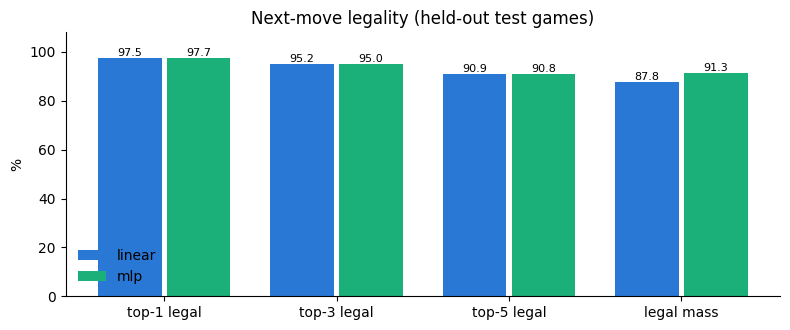

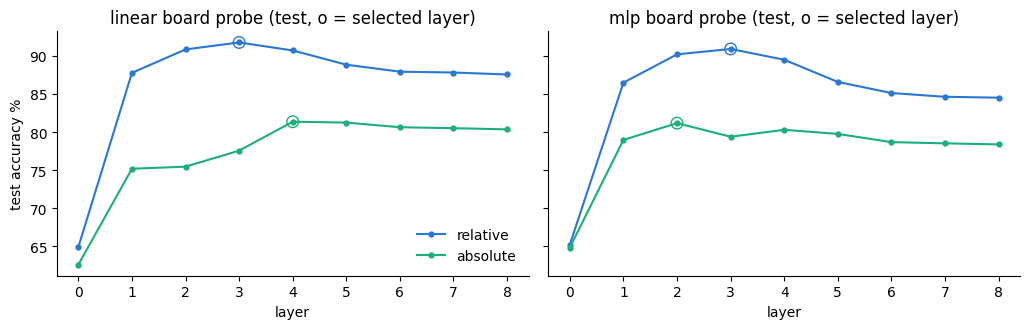

summary: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/summary__unified_eval_v2.md
results: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_k4_hd_run_001_allpos_bf16/unified_eval/final/results__unified_eval_v2.json


In [ ]:
from IPython.display import Markdown, display
summary_path = evaluator.write_summary()
display(Markdown(Path(summary_path).read_text(encoding='utf-8')))

print('=== Frozen next-move readouts: overall legal-move metrics (test split) ===')
_ = show_legal_summary(evaluator.results['frozen_next_move'])
for probe_type in ('linear', 'mlp'):
    probe = evaluator.results['board_state'].get(probe_type)
    if probe:
        print()
        _ = show_board_probe_layers(probe, f'{probe_type.upper()} board probe')

plot_legal_metrics(evaluator.results)
plot_board_probe_layers(evaluator.results)
print('summary:', summary_path)
print('results:', evaluator.results_path)